In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.fdi_classifier import TransferFDIClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Phase 14 Linear Probing on: {device}")

# 1. Ingest Dataset B sliding-window arrays (Phase 13 artifact)
data_path = Path('../data/processed_downstream/fdi_feeder_windows.npz')
data = np.load(data_path)

X_train, y_train = data['X_train'], data['y_train']
X_val, y_val     = data['X_val'],   data['y_val']
X_test, y_test   = data['X_test'],  data['y_test']

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).float().unsqueeze(1)),
    batch_size=64,
    shuffle=True,
    pin_memory=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val).float().unsqueeze(1)),
    batch_size=64,
    shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test).float().unsqueeze(1)),
    batch_size=64,
    shuffle=False
)

# 2. Instantiate Model and Load Pretrained Backbone
model = TransferFDIClassifier(
    in_channels=12,
    pretrained_channels=25,
    cnn_hidden_dims=(64, 128),
    lstm_hidden_dim=128,
    lstm_layers=2,
    mlp_hidden_dim=64,
    dropout=0.3,
    freeze_backbone=True
).to(device)

pretrained_checkpoint = Path('../saved_models/ssl_cnn_bilstm.pth')
model.load_pretrained_backbone(pretrained_checkpoint, device)

# Parameter audit
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"\n--- Model Parameter Allocation ---")
print(f"Total Parameters:     {total_params:,}")
print(f"Frozen Backbone:      {frozen_params:,} (Pretrained CNN + BiLSTM)")
print(f"Trainable Parameters: {trainable_params:,} (Projector + Classification Head)")

Executing Phase 14 Linear Probing on: cuda
[SUCCESS] Loaded Pretrained Encoder Backbone from: ..\saved_models\ssl_cnn_bilstm.pth

--- Model Parameter Allocation ---
Total Parameters:     716,358
Frozen Backbone:      699,392 (Pretrained CNN + BiLSTM)
Trainable Parameters: 16,966 (Projector + Classification Head)


In [2]:
# Compute positive class weight from Phase 13 training statistics
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
pos_weight = torch.tensor([num_neg / num_pos], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Only trainable parameters (head + projector) receive gradient updates
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-3,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

EPOCHS = 25
best_val_f1 = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

print(f"--- Training Frozen Probe Classifier ({EPOCHS} Epochs) ---")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        
        logits = model(x_b)
        loss = criterion(logits, y_b)
        loss.backward()
        
        optimizer.step()
        running_loss += loss.item() * len(x_b)
        
    train_loss = running_loss / len(train_loader.dataset)
    
    # Validation
    model.eval()
    val_loss_accum = 0.0
    all_val_preds, all_val_targets = [], []
    
    with torch.no_grad():
        for x_b, y_b in val_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            logits = model(x_b)
            loss = criterion(logits, y_b)
            val_loss_accum += loss.item() * len(x_b)
            
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).int().cpu().numpy()
            all_val_preds.extend(preds.flatten())
            all_val_targets.extend(y_b.cpu().numpy().flatten())
            
    val_loss = val_loss_accum / len(val_loader.dataset)
    val_f1 = f1_score(all_val_targets, all_val_preds)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), '../saved_models/fdi_frozen_best.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1*100:.2f}%")

print(f"\nTraining Complete. Best Validation F1-Score: {best_val_f1*100:.2f}%")

--- Training Frozen Probe Classifier (25 Epochs) ---
Epoch [01/25] | Train Loss: 0.8869 | Val Loss: 0.9140 | Val F1: 0.00%
Epoch [05/25] | Train Loss: 0.6382 | Val Loss: 1.7881 | Val F1: 29.13%
Epoch [10/25] | Train Loss: 0.4555 | Val Loss: 1.6515 | Val F1: 25.92%
Epoch [15/25] | Train Loss: 0.3747 | Val Loss: 1.5731 | Val F1: 26.95%
Epoch [20/25] | Train Loss: 0.3438 | Val Loss: 1.6339 | Val F1: 21.05%
Epoch [25/25] | Train Loss: 0.3390 | Val Loss: 1.6017 | Val F1: 19.13%

Training Complete. Best Validation F1-Score: 35.43%


PHASE 14 TEST EVALUATION (FROZEN PRETRAINED BACKBONE)
Accuracy:  68.35%
Precision: 16.39%
Recall:    14.29%
F1-Score:  15.27%
ROC-AUC:   51.66%

Confusion Matrix:
[[689 153]
 [180  30]]


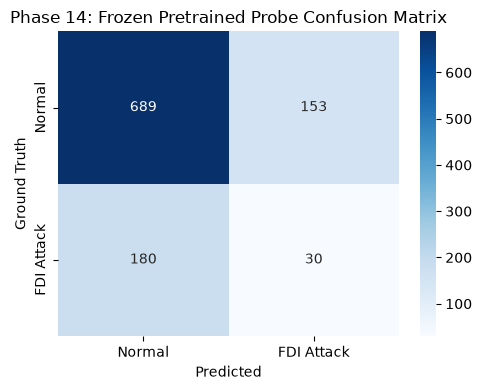

In [3]:
# Load the best frozen checkpoint for holdout testing
model.load_state_dict(torch.load('../saved_models/fdi_frozen_best.pth', map_location=device, weights_only=True))
model.eval()

all_probs, all_preds, all_targets = [], [], []

with torch.no_grad():
    for x_b, y_b in test_loader:
        x_b = x_b.to(device)
        logits = model(x_b)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        preds = (probs >= 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_targets.extend(y_b.numpy().flatten())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Compute Test Metrics
acc  = accuracy_score(all_targets, all_preds)
prec = precision_score(all_targets, all_preds)
rec  = recall_score(all_targets, all_preds)
f1   = f1_score(all_targets, all_preds)
auc  = roc_auc_score(all_targets, all_probs)
cm   = confusion_matrix(all_targets, all_preds)

print("=" * 60)
print("PHASE 14 TEST EVALUATION (FROZEN PRETRAINED BACKBONE)")
print("=" * 60)
print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall:    {rec * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")
print(f"ROC-AUC:   {auc * 100:.2f}%")
print(f"\nConfusion Matrix:\n{cm}")
print("=" * 60)

# Visual Confusion Matrix
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'FDI Attack'],
            yticklabels=['Normal', 'FDI Attack'])
plt.xlabel('Predicted')
plt.ylabel('Ground Truth')
plt.title('Phase 14: Frozen Pretrained Probe Confusion Matrix')
plt.tight_layout()
plt.savefig(fig_dir / 'phase14_frozen_confusion_matrix.png', dpi=300)
plt.show()